In [32]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess-trex",
    neutrons=1_000_000,
    pulses=2,
    optimize_for=trex.choppers,
)
res_elastic_rrm16 = trex.run()
sample = Sample(en={"uniform": (40, 50)})
res_inelastic_rrm16 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_4488/4087431244.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


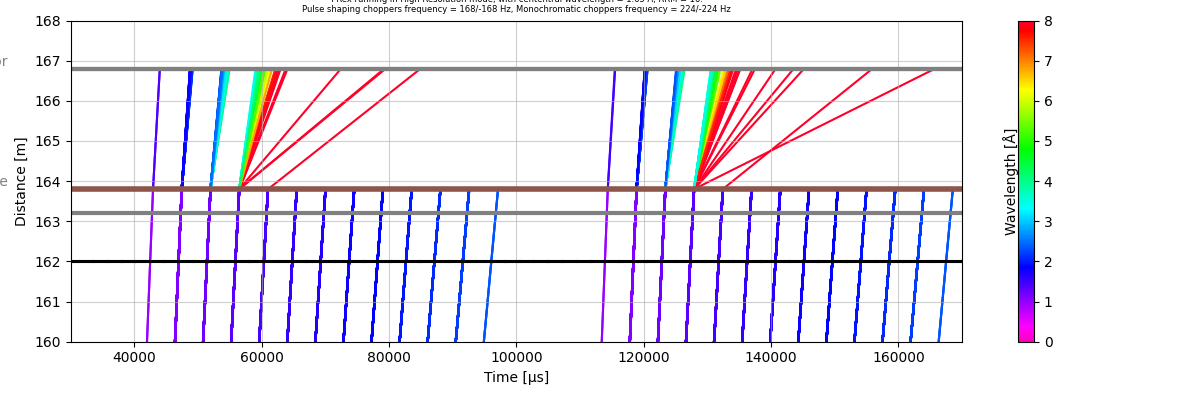

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm16.plot(ax=ax, vmin=0, vmax=8)
ax.set_xlim([30_000, 170_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [34]:
import plopp as pp

data = res_inelastic_rrm16.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=1000), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_4488/2470848905.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


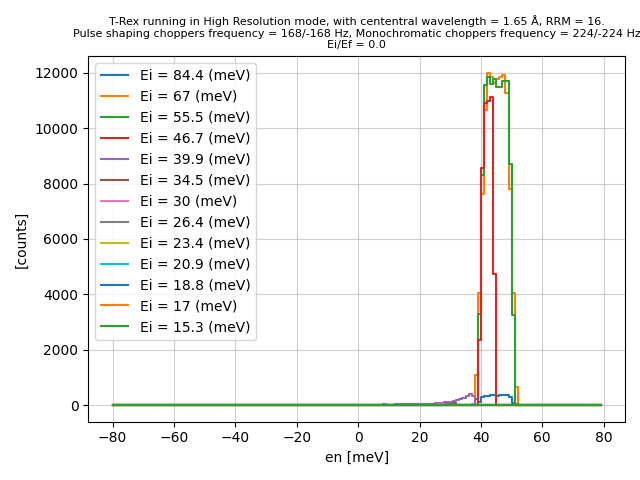

In [35]:
import plopp as pp

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [36]:
reduced_ins[0]

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:3579, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [2184.85, 2185.62, ..., 2151.73, 2153.16]
* birth_wavelength          float64             [Å]  (pulse, event)  [0.984004, 0.98399, ..., 0.985461, 0.98545]
* distance                  float64              [m]  ()  166.8
* ef                        float64            [meV]  (pulse, event)  [45.3952, 45.3121, ..., 33.4604, 33.2734]
* ei                        float64            [meV]  ()  84.3942
* en                        float64            [meV]  (pulse, event)  [38.999, 39.0821, ..., 50.9338, 51.1208]
* eto                       float64            [µs]  (pulse, event)  [43943.7, 43944.6, ..., 44111.4, 44114.7]
* id                          int64        <no unit>  (pulse, event)  [880447, 681266, ..., 477989, 445643]
* kf_over_ki                float64  [dimensionless]  (pulse, event)  [0.725548, 0.725014, ..., 0.639263, 0.637958]
* speed                     float64            [m/s]  (pulse, event)  [2916.95, 2914.84, ..., 2566.26, 2561.05]
* toa                       float64            [µs]  (pulse, event)  [43943.7, 43944.6, ..., 44111.4, 44114.7]
* wavelength                float64             [Å]  (pulse, event)  [1.35622, 1.3572, ..., 1.54156, 1.54469]
Data:
                            float64         [counts]  (pulse, event)  [0.989276, 0.989453, ..., 1.01524, 1.01601]
Masks:
  blocked_by_others            bool        <no unit>  (pulse, event)  [False, False, ..., False, False]

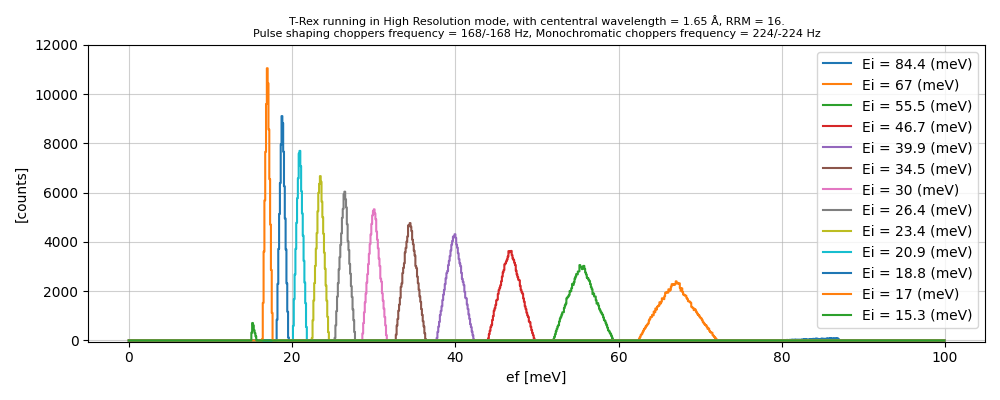

In [37]:
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm16, *params)
# for reduced in reduced_ins:
#     reduced.data *= reduced.coords["kf_over_ki"]
#     reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [38]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess-trex",
    neutrons=1_000_000,
    pulses=2,
    optimize_for=trex.choppers,
)
res_elastic_rrm8 = trex.run()
res_inelastic_rrm8 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_4488/2222359507.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


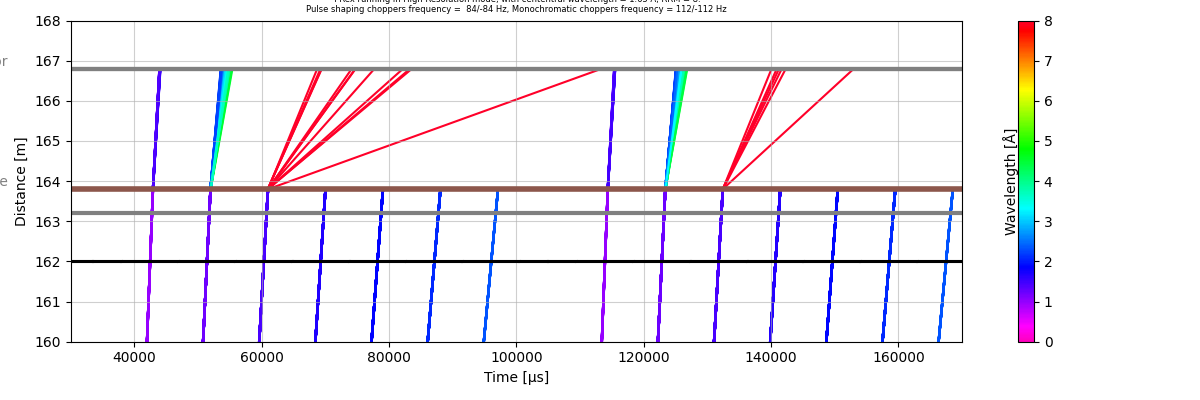

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm8.plot(ax=ax, vmin=0, vmax=8)
ax.set_xlim([30_000, 170_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

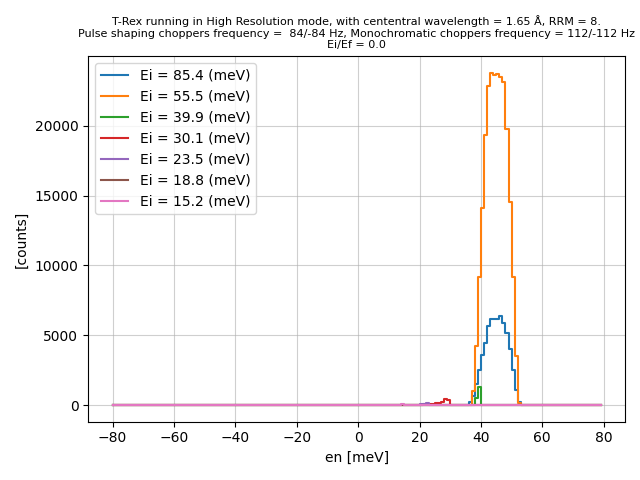

In [40]:
ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm8, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

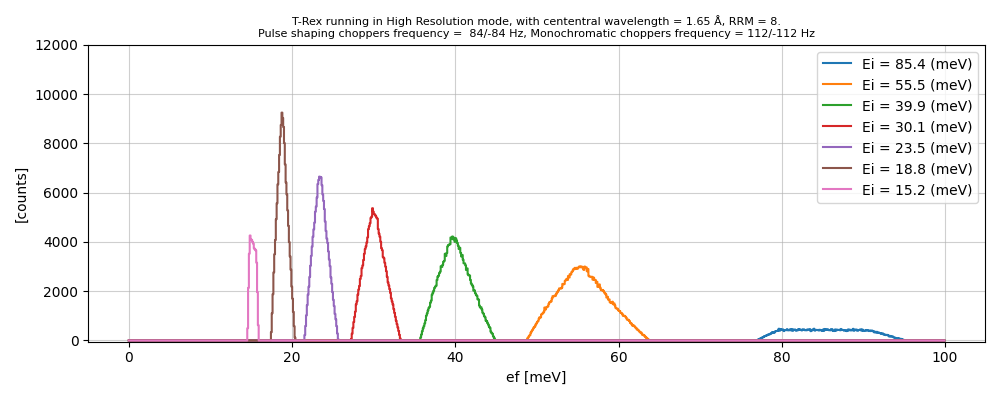

In [41]:
reduced_list = trex.toa_to_energy(res_elastic_rrm8, *params)
# for reduced in reduced_ins:
#     reduced.data *= reduced.coords["kf_over_ki"]
#     reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [42]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 4
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess-trex",
    neutrons=1_000_000,
    pulses=2,
    optimize_for=trex.choppers,
)
res_elastic_rrm4 = trex.run()
res_inelastic_rrm4 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_4488/3583299062.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


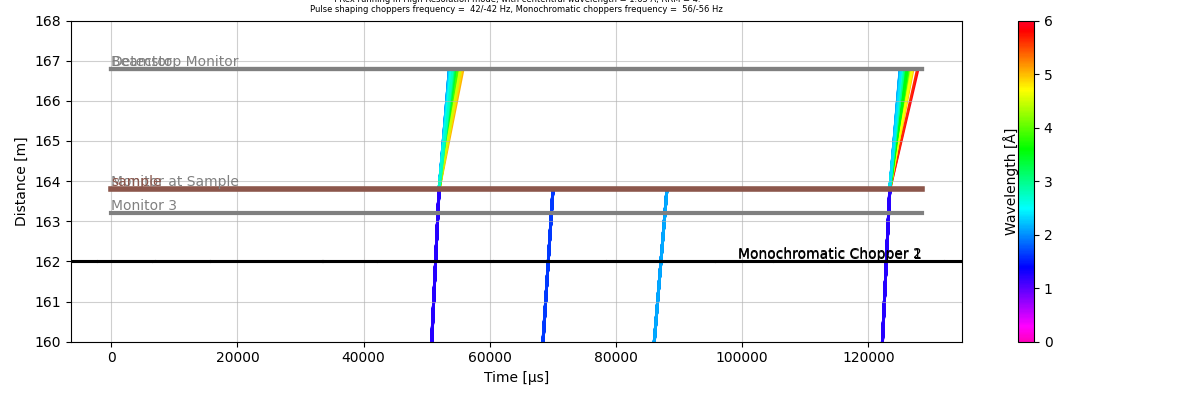

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm4.plot(ax=ax, vmin=0, vmax=6)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

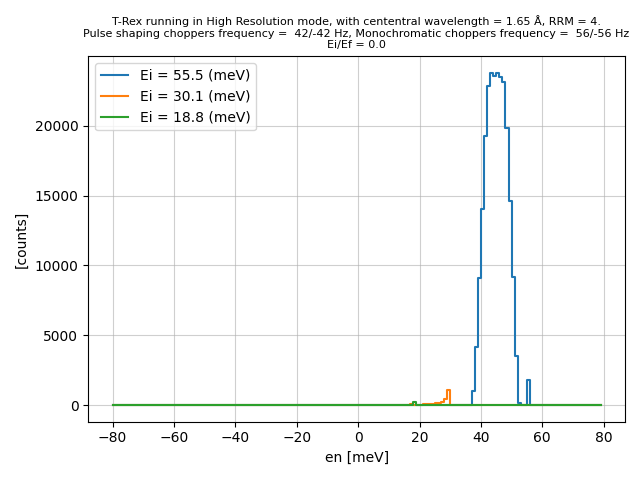

In [44]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm4)
params = trex.unwrap_frame(res_elastic_rrm4, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

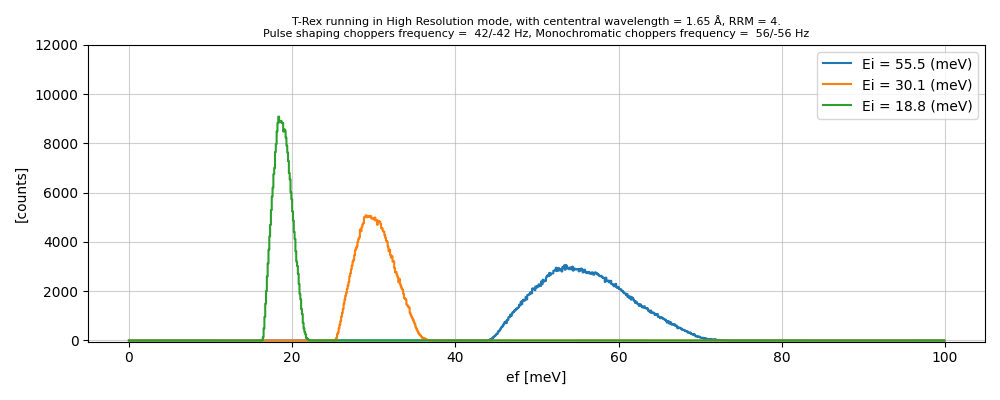

In [45]:
reduced_list = trex.toa_to_energy(res_elastic_rrm4, *params)
# for reduced in reduced_ins:
#     reduced.data *= reduced.coords["kf_over_ki"]
#     reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 12_000])
fig.tight_layout()